<a href="https://colab.research.google.com/github/omrizt17-art/SustainedAttension_EC_EO_ACW_Preprocessed/blob/main/SustainedAttentionTask_ACW_EC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# ============================================================
# SOURCE LOCALIZATION + TIMESCALE ESTIMATION PIPELINE (128 Hz)
# ============================================================
# Goal:
#   For each subject:
#     1) Read EEG (EEGLAB .set/.fdt)
#     2) Preprocess (filter, montage, rereference, resample)
#     3) Source-localize on fsaverage (forward + inverse)
#     4) Extract ROI time series (aparc/DK atlas)
#     5) Compute ROI PSD → fit aperiodic knee (fk) → tau_knee
#     6) Compute ROI autocorrelation decay → tau_AC
#     7) Save per-subject results to CSV
#
#   After looping all subjects:
#     8) Concatenate all subjects into df_all
#     9) Compute ROI means across subjects (df_mean)
#    10) Plot cluster-level and ROI-level summaries
#    11) Hemisphere comparisons on ROI means
!pip install -q mne numpy scipy pandas matplotlib seaborn
!pip install -q mne pyvista pyvistaqt ipywidgets seaborn pymatreader


import os, glob
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.signal import welch, correlate

from mne.datasets import fetch_fsaverage
from mne.minimum_norm import make_inverse_operator, apply_inverse_epochs
from mne import extract_label_time_course


In [38]:
# ============================================================
# 0) COLAB + DRIVE SETUP
#    - Mount Drive
#    - Define a project root
#    - Make MNE downloads persistent (fsaverage, etc.)
# ============================================================

from google.colab import drive
import os

drive.mount("/content/drive")

# Project root folder in Drive
PROJECT_DIR = "/content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Store MNE downloads here so fsaverage/BEM are cached between sessions
import mne
mne.set_config("MNE_DATA", os.path.join(PROJECT_DIR, "mne_data"), set_env=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("MNE_DATA:", mne.get_config("MNE_DATA"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned
MNE_DATA: /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data


In [34]:
import os, glob

files = glob.glob("/content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/*.fif")

ec_subs = sorted({os.path.basename(f).split("_")[0] for f in files if "ECOFF" in f})
eo_subs = sorted({os.path.basename(f).split("_")[0] for f in files if "EOOFF" in f})

print(ec_subs == eo_subs)

True


In [39]:
#location to save results
import os

RESULTS_DIR = "/content/drive/MyDrive/tiw_project_EO_EC/acw_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Results folder:", RESULTS_DIR)

Results folder: /content/drive/MyDrive/tiw_project_EO_EC/acw_results


In [43]:
import os, glob

DATA_DIR = "/content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned"
set_files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_task-ECOFF_run-1_preproc_raw.fif")))

print("Found", len(set_files), "ECOFF files")

Found 28 ECOFF files


In [36]:
# ============================================================
# A) INPUTS: data folder + which files to run
# ============================================================

import glob

DATA_DIR = PROJECT_DIR
set_files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_task-ECOFF_run-1_preproc_raw.fif")))
CONDITION = "EC"
print("Found", len(set_files), "ECOFF files")
print("Example files:", set_files[:3])

# sanity check a single file
if len(set_files) > 0:
    print("First file exists:", os.path.exists(set_files[0]))

Found 27 ECOFF files
Example files: ['/content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/sub-001_task-ECOFF_run-1_preproc_raw.fif', '/content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/sub-002_task-ECOFF_run-1_preproc_raw.fif', '/content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/sub-004_task-ECOFF_run-1_preproc_raw.fif']
First file exists: True


In [20]:
!ls /content/drive/MyDrive/tiw_project_EO_EC

acw_results  preprocessed_manual


In [19]:
# Create MNE data directory manually
MNE_DATA_DIR = os.path.join(PROJECT_DIR, "mne_data")
os.makedirs(MNE_DATA_DIR, exist_ok=True)

import mne
mne.set_config("MNE_DATA", MNE_DATA_DIR, set_env=True)

print("MNE_DATA set to:", mne.get_config("MNE_DATA"))


MNE_DATA set to: /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data


In [6]:
# ============================================================
# B) FSAVERAGE SETUP: everything needed for source localization
#    (done ONCE, outside the subject loop)
# ============================================================

# ---- 1) Fetch fsaverage + subjects_dir ----
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = os.path.dirname(fs_dir)
subject = "fsaverage"

# ---- 2) Source space (lightweight oct5) ----
src = mne.setup_source_space(
    subject=subject,
    spacing="oct5",
    subjects_dir=subjects_dir,
    add_dist=False
)

# ---- 3) BEM model (3-layer EEG) + solution ----
conductivity = (0.3, 0.006, 0.3)  # scalp, skull, brain
bem_model = mne.make_bem_model(
    subject=subject,
    ico=4,
    conductivity=conductivity,
    subjects_dir=subjects_dir
)
bem = mne.make_bem_solution(bem_model)


179 files missing from root.txt in /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data/MNE-fsaverage-data


  0%|                                               | 0.00/196M [00:00<?, ?B/s]

Extracting missing files
Successfully extracted 179 files
10 files missing from bem.txt in /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data/MNE-fsaverage-data/fsaverage


  0%|                                               | 0.00/239M [00:00<?, ?B/s]

Extracting missing files
Successfully extracted 10 files
Setting up the source space with the following parameters:

SUBJECTS_DIR = /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data/MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Octahedron subdivision grade 5

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.white...
Mapping lh fsaverage -> oct (5) ...
    Triangle neighbors and vertex normals...
Loading geometry from /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 1026/163842 selected to source space (oct = 5)

Loading /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data/MNE-fsaverage-data/fsaverage/surf/rh.white...
Map

In [7]:
# ============================================================
# C) ROI / CLUSTER DEFINITIONS: which labels we extract + cluster mapping
#    (done ONCE, outside the subject loop)
# ============================================================

# ROIs chosen to match a hierarchy-style grouping (sensory → parietal → frontal, + insula)
roi_base_names = [
    # Cluster 1: early sensory
    "lingual", "cuneus", "pericalcarine", "lateraloccipital",
    "fusiform", "inferiortemporal", "middletemporal", "bankssts",

    # Cluster 2: dorsal attention / parietal
    "superiorparietal", "inferiorparietal", "precuneus",
    "supramarginal", "posteriorcingulate",

    # Cluster 3: frontal association
    "precentral", "superiorfrontal",
    "caudalmiddlefrontal", "rostralmiddlefrontal",
    "parsopercularis", "parstriangularis", "parsorbitalis",
    "frontalpole",

    # Cluster 4: insula
    "insula"
]

print("\nLoading DKT (aparc) labels…")

labels_all = mne.read_labels_from_annot(
    subject=subject,
    parc="aparc",
    subjects_dir=subjects_dir
)

roi_labels = [
    lab for lab in labels_all
    if lab.name.split("-")[0] in roi_base_names
]

print(f"Found {len(roi_labels)} ROI labels (should be 44 = 22*2 hemispheres):")
for lab in roi_labels:
    print("  ", lab.name)

roi_names = [lab.name for lab in roi_labels]  # stable label names list


# ---- Cluster definitions (base ROI names, no hemisphere suffix) ----
cluster1 = [
    "lingual", "cuneus", "pericalcarine", "lateraloccipital",
    "fusiform", "inferiortemporal", "middletemporal", "bankssts"
]
cluster2 = [
    "superiorparietal", "inferiorparietal", "precuneus",
    "supramarginal", "posteriorcingulate"
]
cluster3 = [
    "precentral", "superiorfrontal",
    "caudalmiddlefrontal", "rostralmiddlefrontal",
    "parsopercularis", "parstriangularis", "parsorbitalis",
    "frontalpole"
]
cluster4 = ["insula"]

roi_cluster = {}
for lab in roi_labels:
    base = lab.name.split("-")[0]
    if base in cluster1:
        roi_cluster[lab.name] = 1
    elif base in cluster2:
        roi_cluster[lab.name] = 2
    elif base in cluster3:
        roi_cluster[lab.name] = 3
    elif base in cluster4:
        roi_cluster[lab.name] = 4
    else:
        roi_cluster[lab.name] = None


# ---- Debug report: confirms ROI presence + cluster assignment ----
print("\n=== ROI DEBUG REPORT ===")

missing = [roi for roi in roi_base_names
           if not any(lab.name.startswith(roi) for lab in labels_all)]
if len(missing) == 0:
    print("✓ All ROI names found in aparc atlas.")
else:
    print("⚠ Missing ROI names:", missing)

cluster_counts = {1: 0, 2: 0, 3: 0, 4: 0, None: 0}
for lab, cl in roi_cluster.items():
    cluster_counts[cl] += 1

print("\nCluster counts:")
for cl, count in cluster_counts.items():
    print(f"  Cluster {cl}: {count} labels")

unassigned = [lab for lab, cl in roi_cluster.items() if cl is None]
if len(unassigned) > 0:
    print("\n⚠ Unassigned labels:")
    for u in unassigned:
        print("   ", u)
else:
    print("✓ No unassigned labels.")

print("=== END OF DEBUG REPORT ===\n")


Loading DKT (aparc) labels…
Reading labels from parcellation...
   read 35 labels from /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /content/drive/MyDrive/tiw_project_EO_EC/preprocessed_manual/cleaned/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot
Found 44 ROI labels (should be 44 = 22*2 hemispheres):
   bankssts-lh
   bankssts-rh
   caudalmiddlefrontal-lh
   caudalmiddlefrontal-rh
   cuneus-lh
   cuneus-rh
   frontalpole-lh
   frontalpole-rh
   fusiform-lh
   fusiform-rh
   inferiorparietal-lh
   inferiorparietal-rh
   inferiortemporal-lh
   inferiortemporal-rh
   insula-lh
   insula-rh
   lateraloccipital-lh
   lateraloccipital-rh
   lingual-lh
   lingual-rh
   middletemporal-lh
   middletemporal-rh
   parsopercularis-lh
   parsopercularis-rh
   parsorbitalis-lh
   parsorbitalis-rh
   parstriangularis-lh
   parstriangularis-rh
   pericalcarine-lh
   pericalcarine-rh


In [ ]:
# @title
import numpy as np
import mne
from mne.preprocessing import ICA, find_eog_events, create_eog_epochs

def add_eog_proxy(raw, frontal_chs=("Fp1", "Fp2", "AF7", "AF8"), new_name="EOGproxy"):
    """
    Create a synthetic EOG channel by averaging frontal EEG channels.
    Returns: raw_with_proxy, proxy_name, channels_used
    """
    picks = [ch for ch in frontal_chs if ch in raw.ch_names]
    if len(picks) == 0:
        raise RuntimeError(f"No frontal channels found from {frontal_chs}. Cannot build EOG proxy.")

    frontal_data = raw.copy().pick(picks).get_data()          # (n_frontal, n_times)
    proxy = frontal_data.mean(axis=0, keepdims=True)          # (1, n_times)

    info = mne.create_info([new_name], sfreq=raw.info["sfreq"], ch_types=["eog"])
    proxy_raw = mne.io.RawArray(proxy, info)

    raw_with_proxy = raw.copy().add_channels([proxy_raw], force_update_info=True)
    return raw_with_proxy, new_name, picks


def run_ica_remove_blinks(raw, method="fastica", random_state=97,
                          frontal_chs=("Fp1", "Fp2", "AF7", "AF8"),
                          eog_threshold=3.0):
    """
    1) Add EOG proxy
    2) Fit ICA on high-passed copy (1 Hz) for stability
    3) Find EOG-like components via correlation with proxy
    4) Exclude them and apply ICA to broadband data
    Returns: cleaned_raw_with_proxy, ica, (eog_inds, eog_scores), eog_name
    """
    # 1) Add proxy
    raw_p, eog_name, picks_used = add_eog_proxy(raw, frontal_chs=frontal_chs)
    print("EOG proxy built from channels:", picks_used)

    # 2) Fit ICA on high-passed copy (training copy only)
    raw_ica = raw_p.copy().filter(l_freq=1.0, h_freq=None, fir_design="firwin")
    picks_eeg = mne.pick_types(raw_ica.info, eeg=True, eog=False, exclude="bads")

    ica = ICA(
        n_components=0.99,
        method=method,
        random_state=random_state,
        max_iter="auto"
    )
    ica.fit(raw_ica, picks=picks_eeg, decim=3)
    print(f"ICA fitted: {ica.n_components_} components.")

    # 3) Identify ocular components (scores = corr(IC, EOGproxy))
    eog_inds, eog_scores = ica.find_bads_eog(raw_ica, ch_name=eog_name, threshold=eog_threshold)
    ica.exclude = eog_inds
    print("EOG-like ICA components marked for exclusion:", eog_inds)

    # 4) Apply ICA to broadband data (raw_p is broadband; raw_ica is only for fitting)
    cleaned = ica.apply(raw_p.copy())
    print("ICA applied.")

    return cleaned, ica, (eog_inds, eog_scores), eog_name


def detect_blink_events(raw_with_proxy, eog_name="EOGproxy"):
    """Return MNE events array for detected blinks in the given EOG channel."""
    events = find_eog_events(raw_with_proxy, ch_name=eog_name)
    print("Detected blink events:", len(events))
    return events


def sanity_check_blinks(raw_with_proxy, eog_name="EOGproxy"):
    """Create blink-locked epochs + evoked average for quick QC."""
    eog_epochs = create_eog_epochs(raw_with_proxy, ch_name=eog_name, baseline=(-0.2, -0.05))
    evoked = eog_epochs.average()
    return eog_epochs, evoked


In [8]:
# helper functions
import numpy as np

def compute_acw(signal, sfreq):
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)

    if np.allclose(signal, 0):
        return np.nan

    acf = np.correlate(signal, signal, mode='full')
    acf = acf[acf.size // 2:]

    if acf[0] == 0:
        return np.nan

    acf = acf / acf[0]

    below = np.where(acf < 0.5)[0]
    if len(below) == 0:
        return np.nan

    lag = below[0]
    acw = lag / sfreq
    return acw


def compute_acw_sliding(raw, window_sec=5, step_sec=1):
    """Compute ACW per EEG channel for each sliding window."""
    data = raw.get_data(picks='eeg')
    sfreq = raw.info['sfreq']

    window = int(window_sec * sfreq)
    step = int(step_sec * sfreq)
    n_samples = data.shape[1]

    acw_epochs = []

    for start in range(0, n_samples - window + 1, step):
        stop = start + window
        segment = data[:, start:stop]

        acw_channels = []
        for ch in segment:
            acw = compute_acw(ch, sfreq)
            acw_channels.append(acw)

        acw_epochs.append(acw_channels)

    return np.array(acw_epochs)


def summarize_acw_epochs(acw_epochs):
    mean_per_window = np.nanmean(acw_epochs, axis=1)   # ACW over time (avg across channels)
    mean_per_channel = np.nanmean(acw_epochs, axis=0)  # ACW over space (avg across windows)
    grand_mean = np.nanmean(acw_epochs)                # overall ACW (avg over everything)
    return mean_per_window, mean_per_channel, grand_mean

In [49]:
# ============================================================
# D) SUBJECT LOOP: compute ROI timescales per subject
# ============================================================

all_subject_dfs = []  # collects each subject's df_tiw

for path_ec in set_files:

    print("\n====================================================")
    print("Processing:", os.path.basename(path_ec))
    print("====================================================")

    # ------------------------------------------------------------
    # 1) Load EEG
    # ------------------------------------------------------------
    raw = mne.io.read_raw_fif(path_ec, preload=True)
    print(raw)

    if "ECG" in raw.ch_names:
        raw.set_channel_types({"ECG": "ecg"})

    raw.set_eeg_reference('average', projection=True)
    # ------------------------------------------------------------
    # 2) Resample to 128 Hz
    # ------------------------------------------------------------
    raw.resample(128)
    sfreq = raw.info['sfreq']
    print("New sampling rate =", sfreq)

    # ------------------------------------------------------------
    # 3) Forward model (fsaverage, EEG only)
    # ------------------------------------------------------------
    trans = "fsaverage"  # default fsaverage transform
    fwd = mne.make_forward_solution(
        raw.info,
        trans=trans,
        src=src,
        bem=bem,
        eeg=True,
        meg=False
    )

    # ------------------------------------------------------------
    # 4) Noise covariance (estimated from the raw resting data)
    # ------------------------------------------------------------
    noise_cov = mne.compute_raw_covariance(raw)

    # ------------------------------------------------------------
    # 5) Inverse operator
    # ------------------------------------------------------------
    inverse_operator = make_inverse_operator(
        raw.info,
        fwd,
        noise_cov,
        loose=0.2,
        depth=0.8
    )
    # ------------------------------------------------------------
    # 6b) ACW-specific epoching (5 s windows, 1 s step)
    # ------------------------------------------------------------
    epochs_acw = mne.make_fixed_length_epochs(
        raw,
        duration=5.0,
        overlap=4.0,   # 5s window with 1s step
        preload=True
    )

    print("Number of ACW epochs =", len(epochs_acw))
    # ------------------------------------------------------------
    # 7) apply inverse per epoch
    # ------------------------------------------------------------
    lambda2 = 1.0 / 9.0
    method = "dSPM"
    stcs_acw = apply_inverse_epochs(
    epochs_acw,
    inverse_operator,
    lambda2=lambda2,
    method=method,
    pick_ori="normal"
    )
    print("Computed", len(stcs_acw), "ACW source epochs.")
    # ------------------------------------------------------------
    # 8) Extract ROI time course
    # ------------------------------------------------------------
    roi_tc_acw = extract_label_time_course(
    stcs_acw,
    labels=roi_labels,
    src=src,
    mode='mean_flip',
    return_generator=False
    )

    roi_tc_acw = np.array(roi_tc_acw)  # shape: (n_windows, n_rois, n_times)
    # ------------------------------------------------------------
    # 9) compute ACW per window per ROI
    # ------------------------------------------------------------
    ACW = {}

    n_windows, n_rois, _ = roi_tc_acw.shape
    acw_epochs = np.full((n_windows, n_rois), np.nan)

    for wi in range(n_windows):
        for ri in range(n_rois):
            sig = roi_tc_acw[wi, ri, :]
            acw_epochs[wi, ri] = compute_acw(sig, sfreq)

    # summarize ACW
    acw_mean_per_window, acw_mean_per_roi, acw_grand_mean = summarize_acw_epochs(acw_epochs)

    for ri, name in enumerate(roi_names):
        ACW[name] = acw_mean_per_roi[ri]

    print("\n✔ Windowed ACW computation completed.\n")
    # ------------------------------------------------------------
    # 10) Build per-subject ACW dataframes + save + append
    # ------------------------------------------------------------
    sub_id = os.path.basename(path_ec).split("_")[0]

    # ---- ROI-level ACW (main results) ----
    results = []
    for name in roi_names:
        results.append({
            "Subject": sub_id,
            "ROI": name,
            "Cluster": roi_cluster[name],
            "ACW_s": ACW[name],
            "ACW_grand_mean_s": acw_grand_mean
        })

    df_acw = pd.DataFrame(results)
    df_acw["Condition"] = CONDITION
    df_acw.to_csv(f"ACW_{sub_id}_{CONDITION}.csv", index=False)
    all_subject_dfs.append(df_acw)

    print(df_acw.head())

    # ---- Time-resolved ACW (per window) ----
    df_acw_time = pd.DataFrame({
        "ACW_window": acw_mean_per_window
    })

    df_acw_time["Subject"] = sub_id
    df_acw_time["Condition"] = CONDITION
    df_acw_time.to_csv(f"ACW_time_{sub_id}_{CONDITION}.csv", index=False)

    print(df_acw_time.head())

Streaming output truncated to the last 5000 lines.
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_flip)
Extracting time courses for 44 labels (mode: mean_fli

In [50]:
# ============================================================
# E) GROUP-LEVEL: concatenate subjects, compute ROI means, and plot
# ============================================================

# ------------------------------------------------------------
# 1) Concatenate all subjects into a single dataframe
# ------------------------------------------------------------
df_all = pd.concat(all_subject_dfs, ignore_index=True)
df_all["Condition"] = CONDITION
df_all.to_csv(f"ACW_ALL_SUBJECTS_{CONDITION}.csv", index=False)

print("\n================ GROUP-LEVEL SUMMARY ================")
print("Rows in df_all:", len(df_all))
print("Unique subjects in df_all:", df_all["Subject"].nunique())
print("First few subjects:", sorted(df_all["Subject"].unique())[:10], "...")
print("=====================================================\n")

print(df_all.head())


# ------------------------------------------------------------
# 2) ROI-level means across subjects (ACW only)
# ------------------------------------------------------------
df_mean = (
    df_all.dropna(subset=["Cluster"])
          .groupby(["Condition", "ROI", "Cluster"], as_index=False)
          .agg({
              "ACW_s": "mean",
              "ACW_grand_mean_s": "mean"
          })
)

df_mean["Cluster"] = df_mean["Cluster"].astype(int)

cluster_names = {
    1: "Early Sensory",
    2: "Parietal / Dorsal",
    3: "Frontal Association",
    4: "Insula"
}

df_mean["ClusterName"] = df_mean["Cluster"].map(cluster_names)


================ GROUP-LEVEL SUMMARY ================
Rows in df_all: 1232
Unique subjects in df_all: 28
First few subjects: ['sub-001', 'sub-002', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011'] ...

   Subject                     ROI  Cluster     ACW_s  ACW_grand_mean_s  \
0  sub-001             bankssts-lh        1  0.016082          0.020823   
1  sub-001             bankssts-rh        1  0.018825          0.020823   
2  sub-001  caudalmiddlefrontal-lh        3  0.016747          0.020823   
3  sub-001  caudalmiddlefrontal-rh        3  0.020819          0.020823   
4  sub-001               cuneus-lh        1  0.021983          0.020823   

  Condition  
0        EC  
1        EC  
2        EC  
3        EC  
4        EC  


In [51]:
# ============================================================
# F) CONTRIBUTION COUNTS
#    How many subjects contributed to each ROI’s mean?
#
# Two useful versions:
#   (1) ROI-level subject count overall (any row exists)
#   (2) ROI-level subject count per metric (non-NaN values)
# ============================================================

# (1) Overall: how many subjects are present for each ROI (regardless of NaNs)
roi_n_subjects_overall = (
    df_all.groupby(["ROI", "Cluster"], as_index=False)["Subject"]
          .nunique()
          .rename(columns={"Subject": "N_Subjects_overall"})
)

# (2) Per metric: how many subjects have a valid value for each metric in each ROI
metrics = ["ACW_s", "ACW_grand_mean_s"]
roi_n_subjects_per_metric = {}

for m in metrics:
    roi_n_subjects_per_metric[m] = (
        df_all.dropna(subset=[m])
              .groupby(["ROI", "Cluster"], as_index=False)["Subject"]
              .nunique()
              .rename(columns={"Subject": f"N_Subjects_{m}"})
    )

# Merge counts into a single table
df_counts = roi_n_subjects_overall.copy()
for m in metrics:
    df_counts = df_counts.merge(roi_n_subjects_per_metric[m], on=["ROI", "Cluster"], how="left")

# Join counts onto df_mean (so you can inspect means + N in one place)
df_mean_withN = df_mean.merge(df_counts, on=["ROI", "Cluster"], how="left")
df_mean_withN["Condition"] = CONDITION

# Save the “means + N” table
df_mean_withN.to_csv(f"ACW_ROI_MEAN_WITH_N_{CONDITION}.csv", index=False)
print(f"Saved ROI mean + contribution counts to: ACW_ROI_MEAN_WITH_N_{CONDITION}.csv")

print(df_mean_withN[[
    "ROI", "Cluster", "ClusterName",
    "N_Subjects_overall",
    "N_Subjects_ACW_s", "N_Subjects_ACW_grand_mean_s"
]].head())

Saved ROI mean + contribution counts to: ACW_ROI_MEAN_WITH_N_EC.csv
                      ROI  Cluster          ClusterName  N_Subjects_overall  \
0             bankssts-lh        1        Early Sensory                  28   
1             bankssts-rh        1        Early Sensory                  28   
2  caudalmiddlefrontal-lh        3  Frontal Association                  28   
3  caudalmiddlefrontal-rh        3  Frontal Association                  28   
4               cuneus-lh        1        Early Sensory                  28   

   N_Subjects_ACW_s  N_Subjects_ACW_grand_mean_s  
0                28                           28  
1                28                           28  
2                28                           28  
3                28                           28  
4                28                           28  


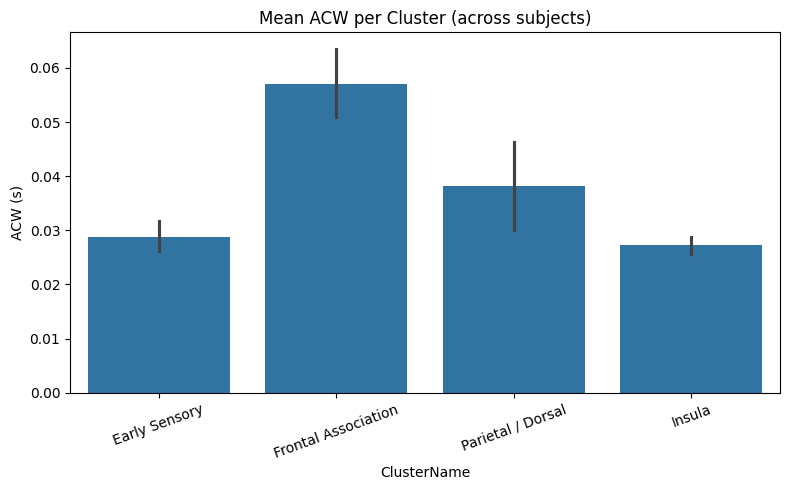

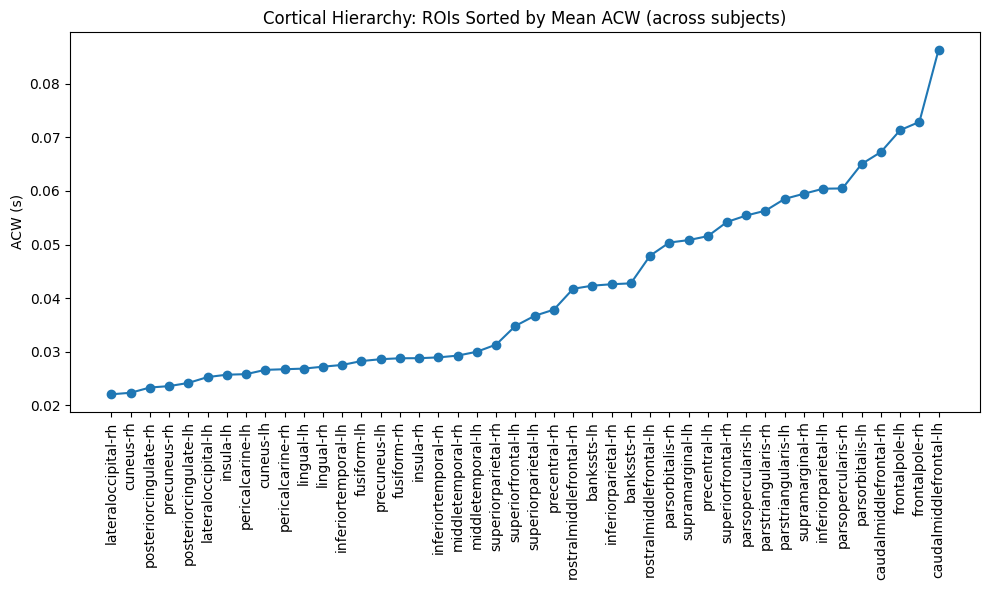

Paired ROIs with both hemispheres: 22


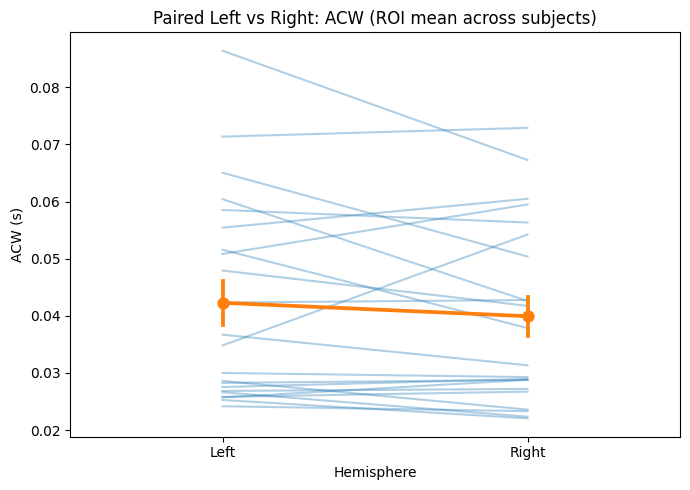

In [52]:
# ============================================================
# G) PLOTS (using ROI means across subjects) -- MINIMAL ACW
# ============================================================

# -----------------------------
# Plot A: Mean ACW by cluster
# -----------------------------
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_mean,
    x="ClusterName",
    y="ACW_s",
    estimator=np.nanmean
)
plt.ylabel("ACW (s)")
plt.title("Mean ACW per Cluster (across subjects)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot B: ROIs sorted by mean ACW (hierarchy view)
# -----------------------------
df_sorted = df_mean.sort_values("ACW_s")

plt.figure(figsize=(10, 6))
plt.plot(df_sorted["ACW_s"].values, "o-")
plt.xticks(
    ticks=np.arange(len(df_sorted)),
    labels=df_sorted["ROI"],
    rotation=90
)
plt.ylabel("ACW (s)")
plt.title("Cortical Hierarchy: ROIs Sorted by Mean ACW (across subjects)")
plt.tight_layout()
plt.show()


# ============================================================
# H) HEMISPHERE COMPARISON (Left vs Right), on ROI means -- ACW
# ============================================================

df_h = df_mean.copy()

# Hemisphere suffix from aparc naming convention: "-lh" / "-rh"
df_h["Hemisphere"] = df_h["ROI"].str.split("-").str[-1].map({"lh": "Left", "rh": "Right"})
df_h["BaseROI"] = df_h["ROI"].str.split("-").str[0]
df_h = df_h.dropna(subset=["Hemisphere", "ACW_s"])

paired = df_h.pivot_table(
    index="BaseROI",
    columns="Hemisphere",
    values="ACW_s",
    aggfunc="mean"
).dropna()

paired_acw = paired.reset_index().melt(
    id_vars="BaseROI",
    var_name="Hemisphere",
    value_name="ACW_s"
)

print(f"Paired ROIs with both hemispheres: {paired.shape[0]}")

# --- Plot C: ACW Left vs Right ---
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=paired_acw,
    x="Hemisphere", y="ACW_s",
    units="BaseROI", estimator=None,
    alpha=0.35
)
sns.pointplot(
    data=paired_acw,
    x="Hemisphere", y="ACW_s",
    errorbar="se"
)
plt.ylabel("ACW (s)")
plt.title("Paired Left vs Right: ACW (ROI mean across subjects)")
plt.tight_layout()
plt.show()

In [53]:
#save to drive for comparison between conditions
save_path = os.path.join(RESULTS_DIR, f"ACW_ALL_SUBJECTS_{CONDITION}.csv")
df_all.to_csv(save_path, index=False)

print("Saved to:", save_path)
print("Shape:", df_all.shape)
display(df_all.head())

Saved to: /content/drive/MyDrive/tiw_project_EO_EC/acw_results/ACW_ALL_SUBJECTS_EC.csv
Shape: (1232, 6)


,Subject,ROI,Cluster,ACW_s,ACW_grand_mean_s,Condition
0,sub-001,bankssts-lh,1,0.016082,0.020823,EC
1,sub-001,bankssts-rh,1,0.018825,0.020823,EC
2,sub-001,caudalmiddlefrontal-lh,3,0.016747,0.020823,EC
3,sub-001,caudalmiddlefrontal-rh,3,0.020819,0.020823,EC
4,sub-001,cuneus-lh,1,0.021983,0.020823,EC
